# Guia practica: globo de medicion de variables meteorologicas

Este notebook implementa una aplicacion numerica real para el oscilador amortiguado que modela el movimiento vertical de un globo cerca de su nivel de boyancia neutra. Se compara el esquema de diferencias centrales con diferencia hacia adelante frente a Euler hacia adelante y frente a la solucion analitica, y al final se incluye una animacion del globo oscilando alrededor del equilibrio.

## Ecuacion del problema

Se resuelve la ecuacion

$$m\,y\ddot{} + b\,y\dot{} + k\,y = 0,$$

con condiciones iniciales genericas

$$y(0)=y_0, \qquad y'(0)=v_0.$$

La discretizacion principal usada en el notebook es

$$y_{n+1} = \frac{2m + bh - kh^2}{m + bh} y_n - \frac{m}{m + bh} y_{n-1},$$

iniciando con un paso de Taylor de segundo orden para construir `y_1`.

In [1]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np
import pandas as pd
from IPython.display import Image, display

plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.5f}'.format

BASE_DIR = Path.cwd().resolve().parents[0]
OUTPUT_DIR = BASE_DIR / 'content' / 'files_globo_medicion'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_PATH = OUTPUT_DIR / 'resumen_globo_medicion.json'


def system_characteristics(m, b, k):
    omega_0 = math.sqrt(k / m)
    alpha = b / (2.0 * m)
    discriminant = alpha**2 - omega_0**2
    if math.isclose(discriminant, 0.0, abs_tol=1e-12):
        regime = 'critico'
    elif discriminant < 0:
        regime = 'subamortiguado'
    else:
        regime = 'sobreamortiguado'
    return {'omega_0': omega_0, 'alpha': alpha, 'discriminant': discriminant, 'regime': regime}


def exact_solution(times, m, b, k, y0, v0):
    props = system_characteristics(m, b, k)
    alpha = props['alpha']
    omega_0 = props['omega_0']
    regime = props['regime']

    if regime == 'subamortiguado':
        omega_d = math.sqrt(omega_0**2 - alpha**2)
        c1 = y0
        c2 = (v0 + alpha * y0) / omega_d
        exp_term = np.exp(-alpha * times)
        cos_term = np.cos(omega_d * times)
        sin_term = np.sin(omega_d * times)
        y = exp_term * (c1 * cos_term + c2 * sin_term)
        v = exp_term * (
            -alpha * (c1 * cos_term + c2 * sin_term)
            + (-c1 * omega_d * sin_term + c2 * omega_d * cos_term)
        )
    elif regime == 'critico':
        c1 = y0
        c2 = v0 + alpha * y0
        exp_term = np.exp(-alpha * times)
        y = exp_term * (c1 + c2 * times)
        v = exp_term * (c2 - alpha * (c1 + c2 * times))
    else:
        root = math.sqrt(alpha**2 - omega_0**2)
        r1 = -alpha + root
        r2 = -alpha - root
        c1 = (v0 - r2 * y0) / (r1 - r2)
        c2 = y0 - c1
        exp1 = np.exp(r1 * times)
        exp2 = np.exp(r2 * times)
        y = c1 * exp1 + c2 * exp2
        v = c1 * r1 * exp1 + c2 * r2 * exp2
    return y, v, props


def central_forward_stepper(m, b, k, y0, v0, dt, t_end):
    times = np.arange(0.0, t_end + dt, dt)
    y = np.zeros_like(times)
    y[0] = y0
    a0 = -(b * v0 + k * y0) / m
    if len(times) > 1:
        y[1] = y0 + v0 * dt + 0.5 * a0 * dt**2
    coeff_1 = (2.0 * m + b * dt - k * dt**2) / (m + b * dt)
    coeff_2 = m / (m + b * dt)
    for n in range(1, len(times) - 1):
        y[n + 1] = coeff_1 * y[n] - coeff_2 * y[n - 1]

    v = np.zeros_like(times)
    if len(times) > 1:
        v[0] = v0
        for n in range(1, len(times) - 1):
            v[n] = (y[n + 1] - y[n - 1]) / (2.0 * dt)
        v[-1] = (y[-1] - y[-2]) / dt

    return times, y, v


def euler_forward_stepper(m, b, k, y0, v0, dt, t_end):
    times = np.arange(0.0, t_end + dt, dt)
    y = np.zeros_like(times)
    v = np.zeros_like(times)
    y[0] = y0
    v[0] = v0
    for n in range(len(times) - 1):
        y[n + 1] = y[n] + dt * v[n]
        v[n + 1] = v[n] + dt * (-(b * v[n] + k * y[n]) / m)
    return times, y, v


def compute_metrics(reference, approximation):
    error = approximation - reference
    return {
        'rmse': float(np.sqrt(np.mean(error**2))),
        'mae': float(np.mean(np.abs(error))),
        'max_abs_error': float(np.max(np.abs(error))),
        'final_error': float(error[-1]),
    }


def discrete_energy(m, k, y, v):
    return 0.5 * m * v**2 + 0.5 * k * y**2


def summarize_case(case):
    y_exact, v_exact, props = exact_solution(
        case['times'], case['m'], case['b'], case['k'], case['y0'], case['v0']
    )
    return {
        'regimen': props['regime'],
        'omega_0': props['omega_0'],
        'alpha': props['alpha'],
        'amplitud_inicial': float(abs(case['y0'])),
        'desplazamiento_final_exacto': float(y_exact[-1]),
        'desplazamiento_final_esquema': float(case['y_scheme'][-1]),
        'desplazamiento_final_euler': float(case['y_euler'][-1]),
        'rmse_esquema': compute_metrics(y_exact, case['y_scheme'])['rmse'],
        'rmse_euler': compute_metrics(y_exact, case['y_euler'])['rmse'],
    }


def make_displacement_plot(main_case):
    fig, ax = plt.subplots(figsize=(11, 5.2))
    ax.plot(main_case['times'], main_case['y_exact'], color='#0f172a', lw=2.2, label='Solucion analitica')
    ax.plot(main_case['times'], main_case['y_scheme'], color='#0f766e', lw=1.6, ls='--', label='Esquema centrado-adelante')
    ax.plot(main_case['times'], main_case['y_euler'], color='#b45309', lw=1.2, alpha=0.9, label='Euler hacia adelante')
    ax.axhline(0.0, color='#64748b', lw=0.9)
    ax.set_title('Comparacion temporal para el caso subamortiguado')
    ax.set_xlabel('Tiempo')
    ax.set_ylabel('Desplazamiento vertical y(t)')
    ax.legend(frameon=False)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    path = OUTPUT_DIR / 'globo_desplazamiento_comparacion.png'
    fig.savefig(path, dpi=180)
    plt.close(fig)
    return path


def make_phase_plot(main_case):
    fig, ax = plt.subplots(figsize=(6.4, 6.0))
    ax.plot(main_case['y_exact'], main_case['v_exact'], color='#0f172a', lw=2.0, label='Solucion analitica')
    ax.plot(main_case['y_scheme'], main_case['v_scheme'], color='#0f766e', lw=1.5, ls='--', label='Esquema centrado-adelante')
    ax.plot(main_case['y_euler'], main_case['v_euler'], color='#b45309', lw=1.0, alpha=0.9, label='Euler hacia adelante')
    ax.set_title('Retrato de fase del globo')
    ax.set_xlabel('y')
    ax.set_ylabel('v = dy/dt')
    ax.legend(frameon=False)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    path = OUTPUT_DIR / 'globo_retrato_fase.png'
    fig.savefig(path, dpi=180)
    plt.close(fig)
    return path


def make_regimes_plot(cases):
    fig, axes = plt.subplots(3, 1, figsize=(10.5, 10.0), sharex=True)
    colors = {
        'subamortiguado': '#0f766e',
        'critico': '#1d4ed8',
        'sobreamortiguado': '#b91c1c',
    }
    for ax, case in zip(axes, cases):
        ax.plot(case['times'], case['y_exact'], color='#111827', lw=2.0, label='Analitica')
        ax.plot(case['times'], case['y_scheme'], color=colors[case['regime']], lw=1.5, ls='--', label='Esquema')
        ax.set_title(f"Caso {case['name']}: b = {case['b']}")
        ax.set_ylabel('y(t)')
        ax.grid(alpha=0.25)
        ax.legend(frameon=False, ncol=2)
    axes[-1].set_xlabel('Tiempo')
    fig.tight_layout()
    path = OUTPUT_DIR / 'globo_regimenes_amortiguamiento.png'
    fig.savefig(path, dpi=180)
    plt.close(fig)
    return path


def make_convergence_plot(study_rows):
    fig, ax = plt.subplots(figsize=(8.8, 5.2))
    ax.loglog(study_rows['dt'], study_rows['rmse_esquema'], marker='o', color='#0f766e', lw=1.8, label='Esquema centrado-adelante')
    ax.loglog(study_rows['dt'], study_rows['rmse_euler'], marker='s', color='#b45309', lw=1.5, label='Euler hacia adelante')
    ax.invert_xaxis()
    ax.set_title('Sensibilidad del error al paso temporal')
    ax.set_xlabel('Paso temporal h')
    ax.set_ylabel('RMSE frente a la solucion analitica')
    ax.legend(frameon=False)
    ax.grid(alpha=0.25, which='both')
    fig.tight_layout()
    path = OUTPUT_DIR / 'globo_convergencia_dt.png'
    fig.savefig(path, dpi=180)
    plt.close(fig)
    return path


def make_energy_plot(main_case):
    energy_exact = discrete_energy(main_case['m'], main_case['k'], main_case['y_exact'], main_case['v_exact'])
    energy_scheme = discrete_energy(main_case['m'], main_case['k'], main_case['y_scheme'], main_case['v_scheme'])
    energy_euler = discrete_energy(main_case['m'], main_case['k'], main_case['y_euler'], main_case['v_euler'])
    fig, ax = plt.subplots(figsize=(10.5, 4.8))
    ax.plot(main_case['times'], energy_exact, color='#0f172a', lw=2.0, label='Analitica')
    ax.plot(main_case['times'], energy_scheme, color='#0f766e', lw=1.5, ls='--', label='Esquema')
    ax.plot(main_case['times'], energy_euler, color='#b45309', lw=1.2, alpha=0.9, label='Euler')
    ax.set_title('Decaimiento de energia mecanica del sistema')
    ax.set_xlabel('Tiempo')
    ax.set_ylabel('Energia')
    ax.legend(frameon=False)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    path = OUTPUT_DIR / 'globo_energia.png'
    fig.savefig(path, dpi=180)
    plt.close(fig)
    return path


def make_animation(main_case):
    times = main_case['times']
    y = main_case['y_scheme']
    step = max(1, len(times) // 240)
    frame_idx = np.arange(0, len(times), step)
    if frame_idx[-1] != len(times) - 1:
        frame_idx = np.append(frame_idx, len(times) - 1)

    fig = plt.figure(figsize=(10.0, 4.6))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.65])
    ax_scene = fig.add_subplot(gs[0, 0])
    ax_time = fig.add_subplot(gs[0, 1])

    y_lim = max(1.15 * np.max(np.abs(y)), 1.0)
    ax_scene.set_xlim(-1.6, 1.6)
    ax_scene.set_ylim(-y_lim - 0.6, y_lim + 0.6)
    ax_scene.axhline(0.0, color='#64748b', lw=1.0, ls='--')
    ax_scene.plot([0.0, 0.0], [-y_lim - 0.5, y_lim + 0.5], color='#cbd5e1', lw=2.0)
    balloon = plt.Circle((0.0, y[0]), 0.18, color='#ef4444', ec='#7f1d1d', lw=1.5)
    ax_scene.add_patch(balloon)
    string_line, = ax_scene.plot([0.0, 0.0], [y[0] - 0.18, y[0] - 0.75], color='#7c2d12', lw=2.0)
    time_text = ax_scene.text(-1.5, y_lim + 0.25, '', fontsize=10)
    ax_scene.set_title('Movimiento vertical del globo')
    ax_scene.set_xticks([])
    ax_scene.set_ylabel('Altura relativa')

    ax_time.plot(times, y, color='#93c5fd', lw=1.2)
    marker_line, = ax_time.plot([], [], color='#1d4ed8', lw=2.0)
    marker_point, = ax_time.plot([], [], 'o', color='#1d4ed8')
    ax_time.axhline(0.0, color='#64748b', lw=0.9)
    ax_time.set_xlim(times[0], times[-1])
    ax_time.set_ylim(-y_lim, y_lim)
    ax_time.set_title('Respuesta numerica y(t)')
    ax_time.set_xlabel('Tiempo')
    ax_time.set_ylabel('y(t)')
    ax_time.grid(alpha=0.25)

    def update(frame):
        idx = frame_idx[frame]
        y_now = y[idx]
        balloon.center = (0.0, y_now)
        string_line.set_data([0.0, 0.0], [y_now - 0.18, y_now - 0.75])
        marker_line.set_data(times[: idx + 1], y[: idx + 1])
        marker_point.set_data([times[idx]], [y_now])
        time_text.set_text(f't = {times[idx]:.2f}')
        return balloon, string_line, marker_line, marker_point, time_text

    anim = FuncAnimation(fig, update, frames=len(frame_idx), interval=50, blit=True)
    gif_path = OUTPUT_DIR / 'globo_oscilacion.gif'
    anim.save(gif_path, writer=PillowWriter(fps=20))
    plt.close(fig)
    return gif_path


main_params = {'m': 1.0, 'k': 1.0, 'b': 0.4, 'y0': 1.0, 'v0': 0.0, 'dt': 0.04, 't_end': 24.0}
main_times = np.arange(0.0, main_params['t_end'] + main_params['dt'], main_params['dt'])
y_exact, v_exact, main_props = exact_solution(main_times, main_params['m'], main_params['b'], main_params['k'], main_params['y0'], main_params['v0'])
_, y_scheme, v_scheme = central_forward_stepper(**main_params)
_, y_euler, v_euler = euler_forward_stepper(**main_params)

main_case = {
    **main_params,
    'name': 'subamortiguado de referencia',
    'regime': main_props['regime'],
    'times': main_times,
    'y_exact': y_exact,
    'v_exact': v_exact,
    'y_scheme': y_scheme,
    'v_scheme': v_scheme,
    'y_euler': y_euler,
    'v_euler': v_euler,
}

cases = []
for name, b_value in [('subamortiguado', 0.4), ('critico', 2.0), ('sobreamortiguado', 3.0)]:
    params = {'name': name, 'm': 1.0, 'k': 1.0, 'b': b_value, 'y0': 1.0, 'v0': 0.0, 'dt': 0.04, 't_end': 24.0}
    times = np.arange(0.0, params['t_end'] + params['dt'], params['dt'])
    y_exact_case, v_exact_case, props = exact_solution(times, params['m'], params['b'], params['k'], params['y0'], params['v0'])
    _, y_scheme_case, v_scheme_case = central_forward_stepper(params['m'], params['b'], params['k'], params['y0'], params['v0'], params['dt'], params['t_end'])
    _, y_euler_case, v_euler_case = euler_forward_stepper(params['m'], params['b'], params['k'], params['y0'], params['v0'], params['dt'], params['t_end'])
    cases.append({
        **params,
        'regime': props['regime'],
        'times': times,
        'y_exact': y_exact_case,
        'v_exact': v_exact_case,
        'y_scheme': y_scheme_case,
        'v_scheme': v_scheme_case,
        'y_euler': y_euler_case,
        'v_euler': v_euler_case,
    })

study_rows = []
for dt_value in [0.40, 0.20, 0.10, 0.05, 0.025]:
    params = {'m': 1.0, 'k': 1.0, 'b': 0.4, 'y0': 1.0, 'v0': 0.0, 'dt': dt_value, 't_end': 24.0}
    times = np.arange(0.0, params['t_end'] + params['dt'], params['dt'])
    y_exact_dt, _, _ = exact_solution(times, params['m'], params['b'], params['k'], params['y0'], params['v0'])
    _, y_scheme_dt, _ = central_forward_stepper(**params)
    _, y_euler_dt, _ = euler_forward_stepper(**params)
    study_rows.append({
        'dt': dt_value,
        'rmse_esquema': compute_metrics(y_exact_dt, y_scheme_dt)['rmse'],
        'rmse_euler': compute_metrics(y_exact_dt, y_euler_dt)['rmse'],
        'max_error_esquema': compute_metrics(y_exact_dt, y_scheme_dt)['max_abs_error'],
        'max_error_euler': compute_metrics(y_exact_dt, y_euler_dt)['max_abs_error'],
    })

study_df = pd.DataFrame(study_rows).sort_values('dt', ascending=False)

figure_paths = {
    'desplazamiento': make_displacement_plot(main_case),
    'fase': make_phase_plot(main_case),
    'regimenes': make_regimes_plot(cases),
    'convergencia': make_convergence_plot(study_df),
    'energia': make_energy_plot(main_case),
}
gif_path = make_animation(main_case)

summary = {
    'caso_principal': summarize_case(main_case),
    'regimenes': {case['name']: summarize_case(case) for case in cases},
    'estudio_dt': study_df.to_dict(orient='records'),
    'figuras': {key: path.name for key, path in figure_paths.items()},
    'animacion': gif_path.name,
}
SUMMARY_PATH.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')
display(pd.DataFrame(summary['regimenes']).T)

,regimen,omega_0,alpha,amplitud_inicial,desplazamiento_final_exacto,desplazamiento_final_esquema,desplazamiento_final_euler,rmse_esquema,rmse_euler
subamortiguado,subamortiguado,1.00000,0.20000,1.00000,-0.00206,-0.00287,-0.00093,0.00311,0.01772
critico,critico,1.00000,1.00000,1.00000,0.00000,-0.00000,0.00000,0.00133,0.00207
sobreamortiguado,sobreamortiguado,1.00000,1.50000,1.00000,0.00012,0.00011,0.00011,0.00104,0.00143


## Caso principal: comparacion temporal

Se parte de un caso subamortiguado de referencia con `m=1`, `k=1`, `b=0.4`, `y0=1`, `v0=0`, `h=0.04` y `t_final=24`. Este es el caso mas util para ver la oscilacion amortiguada del globo y contrastar las tres soluciones.

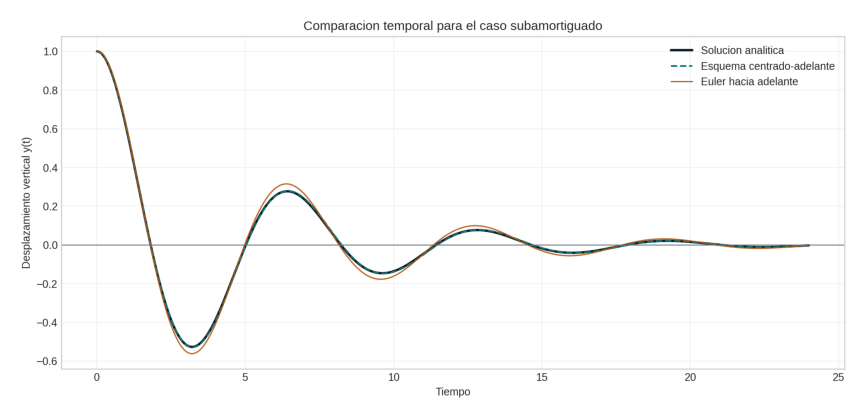

Metricas del caso principal:


regimen                         subamortiguado
omega_0                                1.00000
alpha                                  0.20000
amplitud_inicial                       1.00000
desplazamiento_final_exacto           -0.00206
desplazamiento_final_esquema          -0.00287
desplazamiento_final_euler            -0.00093
rmse_esquema                           0.00311
rmse_euler                             0.01772
dtype: object

In [2]:
image_path = OUTPUT_DIR / 'globo_desplazamiento_comparacion.png'
img = plt.imread(image_path)
plt.figure(figsize=(11, 5.2))
plt.imshow(img)
plt.axis('off')
plt.show()

print('Metricas del caso principal:')
pd.Series(summary['caso_principal'])

## Retrato de fase

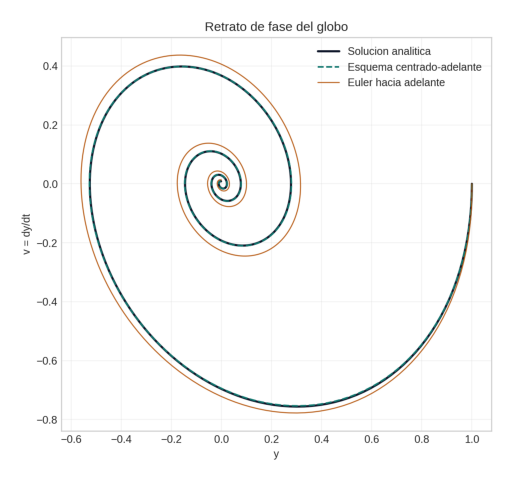

In [3]:
image_path = OUTPUT_DIR / 'globo_retrato_fase.png'
img = plt.imread(image_path)
plt.figure(figsize=(6.4, 6.0))
plt.imshow(img)
plt.axis('off')
plt.show()

## Regimenes de amortiguamiento

Se comparan tres escenarios con los mismos `m`, `k`, `y0` y `v0`, pero con `b` diferente para resaltar las diferencias entre respuesta oscilatoria, critica y sobreamortiguada.

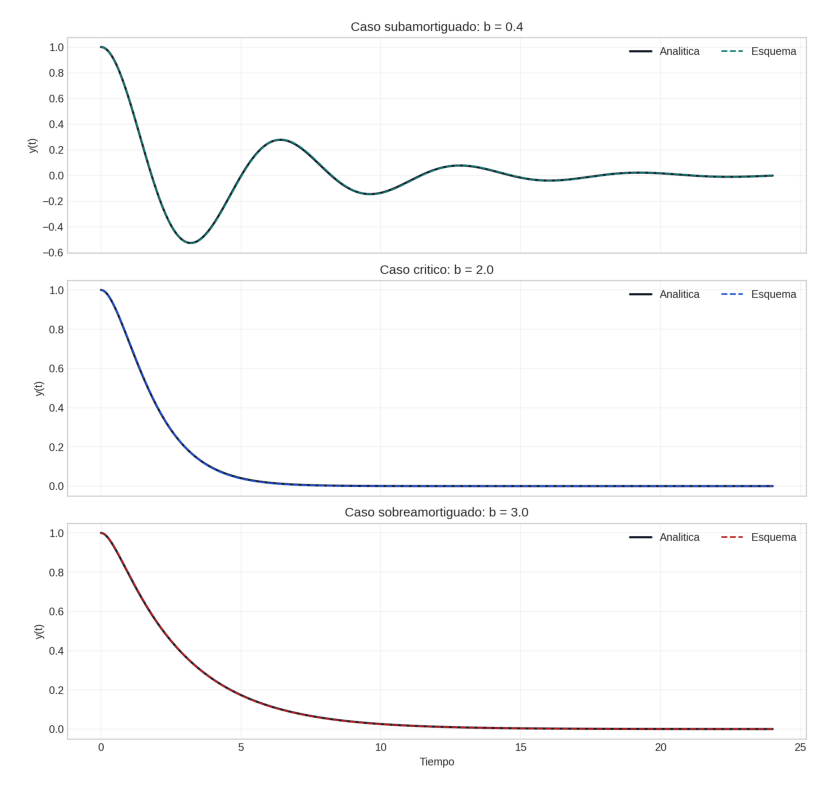

In [4]:
image_path = OUTPUT_DIR / 'globo_regimenes_amortiguamiento.png'
img = plt.imread(image_path)
plt.figure(figsize=(10.5, 10.0))
plt.imshow(img)
plt.axis('off')
plt.show()

## Sensibilidad al paso temporal

Este barrido permite evaluar cuando la discretizacion sigue siendo confiable y cuando Euler comienza a degradarse con mayor rapidez.

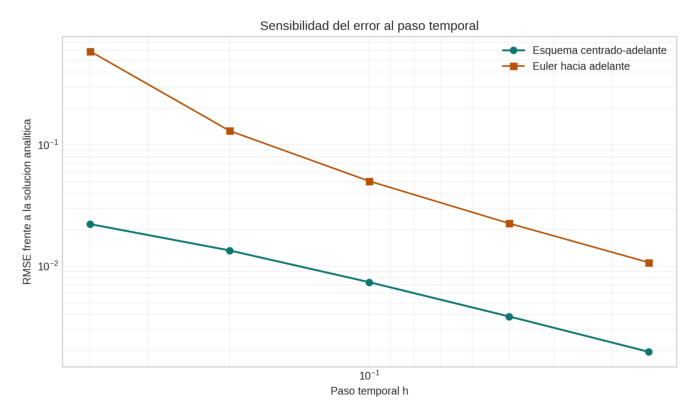

,dt,rmse_esquema,rmse_euler,max_error_esquema,max_error_euler
0,0.40000,0.02227,0.59270,0.04833,1.00960
1,0.20000,0.01350,0.13075,0.03001,0.25534
2,0.10000,0.00739,0.05033,0.01662,0.10762
3,0.05000,0.00386,0.02260,0.00872,0.04956
4,0.02500,0.00197,0.01076,0.00446,0.02381


In [5]:
image_path = OUTPUT_DIR / 'globo_convergencia_dt.png'
img = plt.imread(image_path)
plt.figure(figsize=(8.8, 5.2))
plt.imshow(img)
plt.axis('off')
plt.show()

study_df

## Energia mecanica

Aunque el modelo no incluye una energia conservada por la presencia de amortiguamiento, si debe mostrar una tendencia decreciente compatible con la disipacion por resistencia del aire.

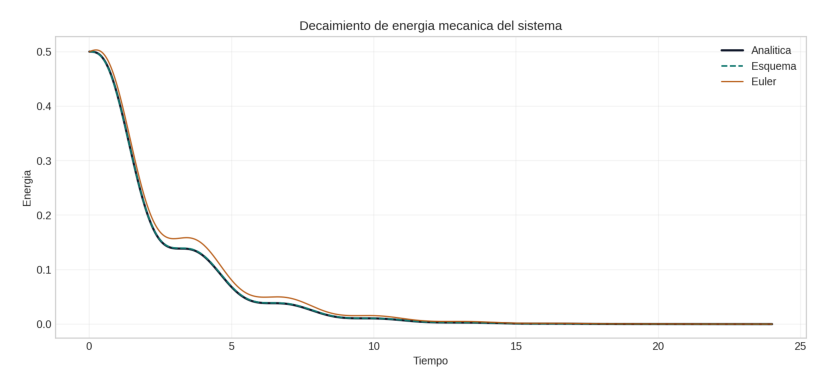

In [6]:
image_path = OUTPUT_DIR / 'globo_energia.png'
img = plt.imread(image_path)
plt.figure(figsize=(10.5, 4.8))
plt.imshow(img)
plt.axis('off')
plt.show()

## Discusion breve

- El esquema centrado-adelante sigue de cerca la solucion analitica en los tres regimens.
- Euler hacia adelante puede capturar la tendencia cualitativa, pero acumula mas error de fase y amplitud.
- Al aumentar `h`, ambos metodos empeoran, aunque el esquema derivado se mantiene mas preciso para el mismo paso.
- La energia decrece con el tiempo, como exige la interpretacion fisica del amortiguamiento.
- En el caso subamortiguado, la oscilacion del globo es visible y su amplitud se atenúa progresivamente.

## Animacion final del globo

La siguiente animacion muestra la posicion vertical del globo y la evolucion temporal de `y(t)` usando la discretizacion derivada en el inciso.

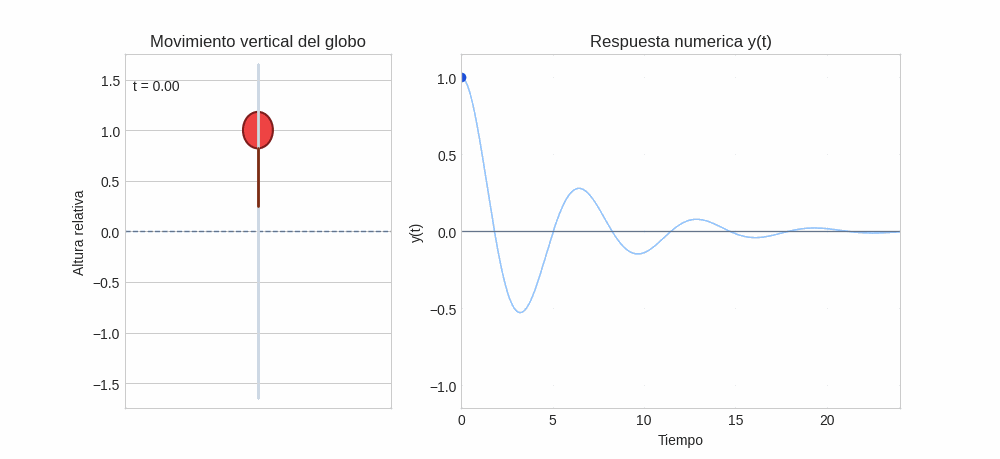

In [7]:
display(Image(filename=str(OUTPUT_DIR / 'globo_oscilacion.gif')))